In [120]:
import numpy as np
import matplotlib.pyplot as plt
from corner import corner

In [121]:
def fitfun(x, pars):
    tau1_ = pars[0]
    tau2_ = pars[1]
    p_tau1_ = pars[2]

    y = p_tau1_*np.exp(-x/tau1_) + (1 - p_tau1_)*np.exp(-x/tau2_)
    return y

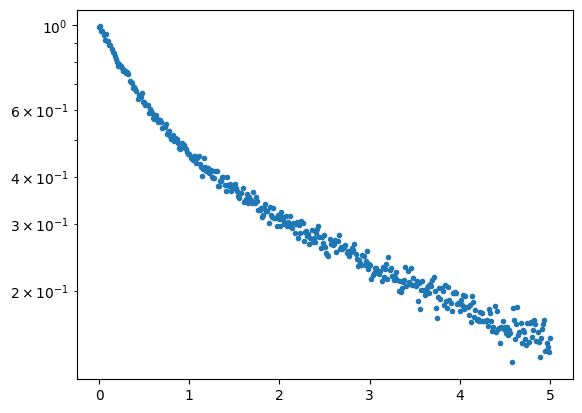

In [122]:
tau1 = 0.5
tau2 = 4
p_tau1 = 0.5
x = np.linspace(0,5,400)
y = fitfun(x, [tau1, tau2, p_tau1]) + 0.01*np.random.randn(400)
err = np.sqrt(y)
#y /= np.sum(y)
plt.semilogy(x,y,".")
plt.show()
def log_likelihood(X):
    tau1_ = X[0]
    tau2_ = X[1]
    p_tau1_ = X[2]
    if (tau1_<0) | (tau2_<0) | (tau1_>tau2_) | (abs(p_tau1_ - 0.5)>0.5) | (tau2_>2*np.max(x)):
        return -np.inf
    y_ = fitfun(x,X)
    f = (y - y_)/err
    return np.sum(-f**2)

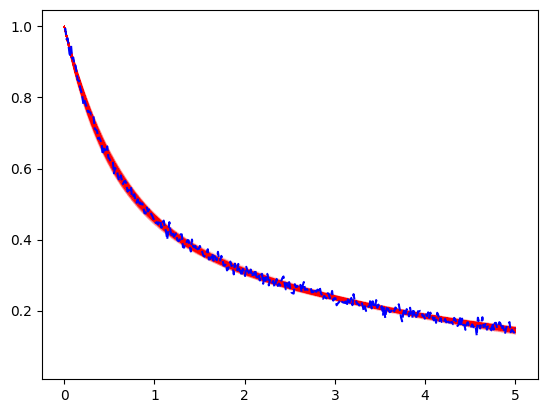

acceptance rate: 0.41428


In [123]:
init_param_guess = [1,5, 0.3]
num_reps = 100000
jump_mag = [0.2,0.5,0.05]
param_its = np.zeros((len(init_param_guess),num_reps))
param_its[:,0] = init_param_guess
rands = np.random.uniform(0,1,(num_reps))
acceptances = 0
loglikes = np.zeros_like(rands)
for i in range(num_reps-1):
    my_likelihood = log_likelihood(param_its[:,i])
    jump = jump_mag * np.random.randn(np.size(init_param_guess))
    loglikes[i] = my_likelihood
    new_params = param_its[:,i] + jump
    new_likelihood = log_likelihood(new_params)
    if rands[i] <np.exp(new_likelihood - my_likelihood):
        param_its[:,i+1] = new_params
        acceptances += 1
    else:
        param_its[:,i+1] = param_its[:,i]
    plt.plot(x,fitfun(x,param_its[:,i]),'r-', alpha = 0.005*(1+np.tanh(my_likelihood))/2)
plt.plot(x,y,'b--')
plt.show()
print("acceptance rate: {}".format(acceptances/num_reps))


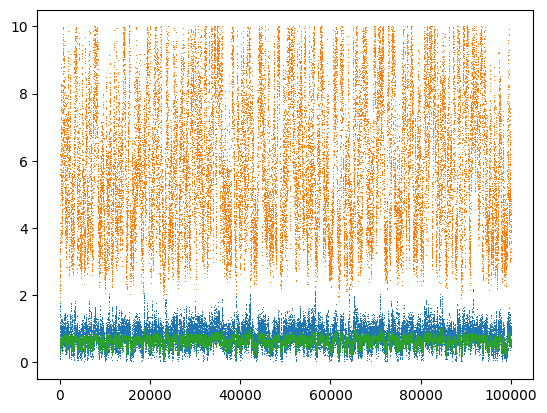

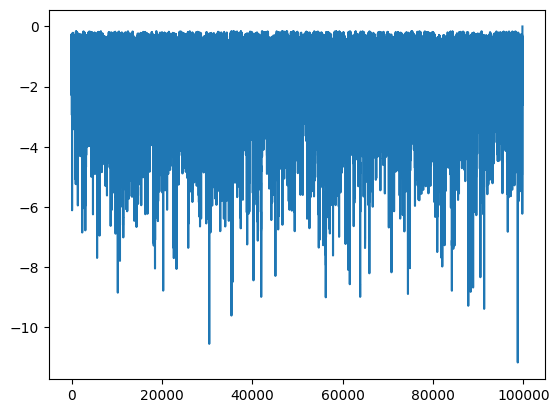

[[0.08651653 0.29767577 0.02911981]
 [0.29767577 4.45917312 0.22742629]
 [0.02911981 0.22742629 0.01749204]]
[0.64132105 4.68126835 0.5801436 ]


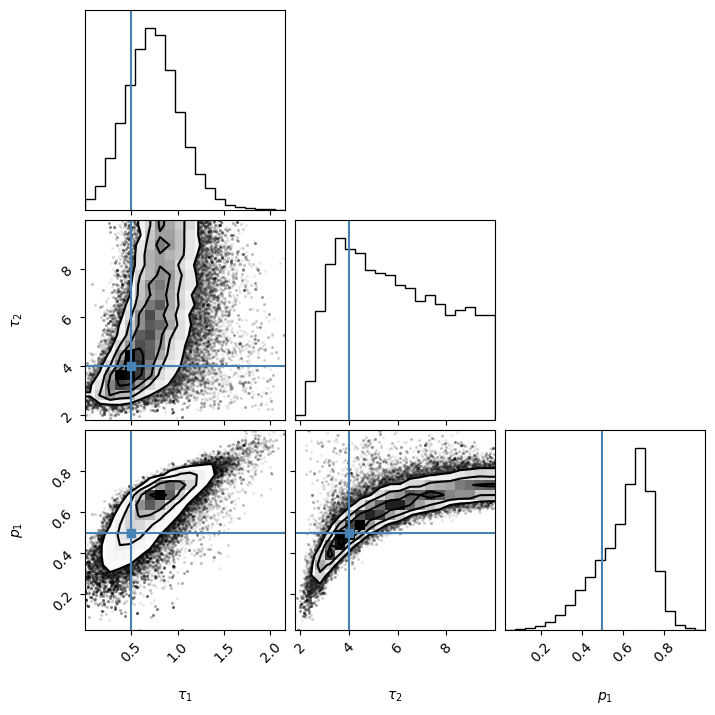

In [135]:
plt.plot(np.arange(num_reps),param_its.T,",")
plt.show()
cutoff = 200
plt.plot(loglikes[cutoff:])
plt.show()
corner(param_its[:,cutoff:].T,labels = [r"$\tau_1$", r"$\tau_2$", r"$p_1$"],truths = [tau1,tau2,p_tau1])
covar = np.cov(param_its[:,cutoff:])
print(covar)
print(param_its[:,np.argmax(loglikes)])
